Plotting Time-Series grid for all files...


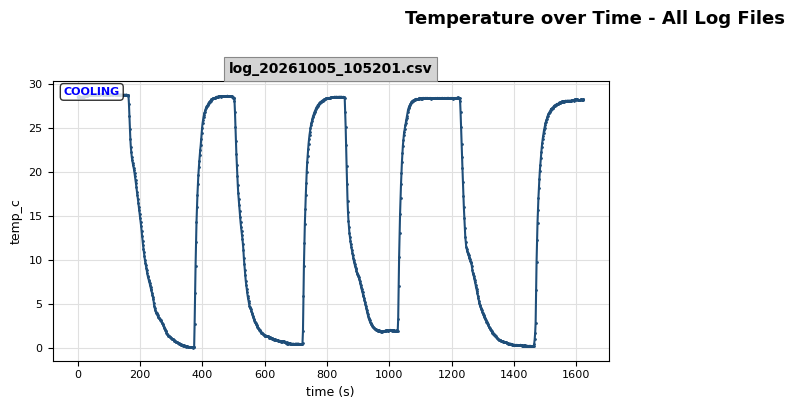


Plot saved as 'temp_vs_time_response.png'
Total files plotted: 1


In [120]:
import os
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# List of CSV files from your git repository
csv_files = [
    "log_20261005_105201.csv",
]

# If files are in a data folder, uncomment this:
folder_path = "../../data"
csv_files = [os.path.join(folder_path, f) for f in csv_files]

def plot_time_series_grid(file_list, n_cols=2):
    """
    Plot temp_c vs time for each file in a grid layout
    """
    n_files = len(file_list)
    if n_files == 0:
        print("No files to plot")
        return
    
    n_rows = math.ceil(n_files / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)
    axes_flat = axes.flatten()
    
    for idx, file_path in enumerate(file_list):
        ax = axes_flat[idx]
        file_name = os.path.basename(file_path)
        
        # Read CSV file
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()
        
        # Check if required columns exist
        if 'temp_c' not in df.columns:
            print(f"Warning: 'temp_c' column not found in {file_name}")
            ax.set_title(file_name, fontsize=10, fontweight='bold',
                        pad=6, bbox=dict(boxstyle="square,pad=0.35", 
                                        facecolor="#d4d4d4", edgecolor="#888888", linewidth=0.8))
            ax.text(0.5, 0.5, 'No temp_c column', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=12, color='red')
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        
        # Plot temp_c vs time
        if 'time_ms' in df.columns:
            # Convert milliseconds to seconds
            t_sec = df['time_ms'] / 1000.0
            ax.plot(t_sec, df['temp_c'], color="#1f4e79", marker='.', markersize=2, linestyle='-')
            ax.set_xlabel("time (s)", fontsize=9)
        elif 'time' in df.columns:
            ax.plot(df['time'], df['temp_c'], color="#1f4e79", marker='.', markersize=2, linestyle='-')
            ax.set_xlabel("time", fontsize=9)
        else:
            # Use index as time
            ax.plot(df.index, df['temp_c'], color="#1f4e79", marker='.', markersize=2, linestyle='-')
            ax.set_xlabel("sample", fontsize=9)
        
        ax.set_ylabel("temp_c", fontsize=9)
        ax.set_title(file_name, fontsize=10, fontweight='bold',
                    pad=6, bbox=dict(boxstyle="square,pad=0.35", 
                                    facecolor="#d4d4d4", edgecolor="#888888", linewidth=0.8))
        
        # Add grid
        ax.grid(True, color="#e0e0e0", linestyle="-", linewidth=0.8)
        ax.tick_params(labelsize=8)
        
        # Determine if heating or cooling based on trend
        if len(df) > 10:
            # Compare first 10% and last 10% of data
            n_samples = len(df)
            first_avg = df['temp_c'].iloc[:n_samples//10].mean()
            last_avg = df['temp_c'].iloc[-n_samples//10:].mean()
            
            if last_avg > first_avg + 1:
                trend = "HEATING"
                color = "red"
            elif last_avg < first_avg - 1:
                trend = "COOLING"
                color = "blue"
            else:
                trend = "STABLE"
                color = "green"
            
            ax.text(0.02, 0.98, trend, transform=ax.transAxes, fontsize=8, 
                   fontweight='bold', color=color, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Hide unused subplots
    for j in range(n_files, len(axes_flat)):
        fig.delaxes(axes_flat[j])
    
    fig.suptitle("Temperature over Time - All Log Files", fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("temp_vs_time_response.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nPlot saved as 'temp_vs_time_response.png'")
    print(f"Total files plotted: {n_files}")

# Run the plot
print("Plotting Time-Series grid for all files...")
plot_time_series_grid(csv_files, n_cols=2)

In [121]:
# ==========================================
# 1. Define the correct file paths
# ==========================================
resposne_file = "../../data/log_20261005_105201.csv"

# ==========================================
# 2. Load RAW Data
# ==========================================
# Heating
raw_response_df = pd.read_csv(resposne_file)
raw_response_df.columns = raw_response_df.columns.str.strip()
raw_response_df['source'] = os.path.basename(resposne_file)


print(f"Raw Heating Data loaded: {len(raw_response_df)} rows")

Raw Heating Data loaded: 1079 rows


In [122]:
raw_response_df.head(3)  # Display first 3 rows of heating data

,time_ms,temp_c,temp_k,adc,source
0,587,28.50,301.65,281,log_20261005_105201.csv
1,2093,28.50,301.65,280,log_20261005_105201.csv
2,3598,28.56,301.71,280,log_20261005_105201.csv


In [123]:
raw_response_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079 entries, 0 to 1078
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   time_ms  1079 non-null   int64  
 1   temp_c   1079 non-null   float64
 2   temp_k   1079 non-null   float64
 3   adc      1079 non-null   int64  
 4   source   1079 non-null   object 
dtypes: float64(2), int64(2), object(1)
memory usage: 42.3+ KB


In [124]:
import matplotlib.pyplot as plt

def plot_adc_vs_temp(x, y, title="ADC vs Temperature", x_label="ADC Value", y_label="Temperature (°C)", color='blue', alpha=0.5):
    """
    Plots ADC values against Temperature (°C).
    
    Parameters:
    - x: array-like, ADC values (e.g., df['adc'])
    - y: array-like, Temperature values in Celsius (e.g., df['temp_c'])
    - title: str, title of the plot
    - x_label: str, label for the x-axis
    - y_label: str, label for the y-axis
    - color: str, color of the scatter points
    - alpha: float, transparency of the scatter points (0.0 to 1.0)
    """
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color=color, alpha=0.6, s=15, edgecolors='none')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

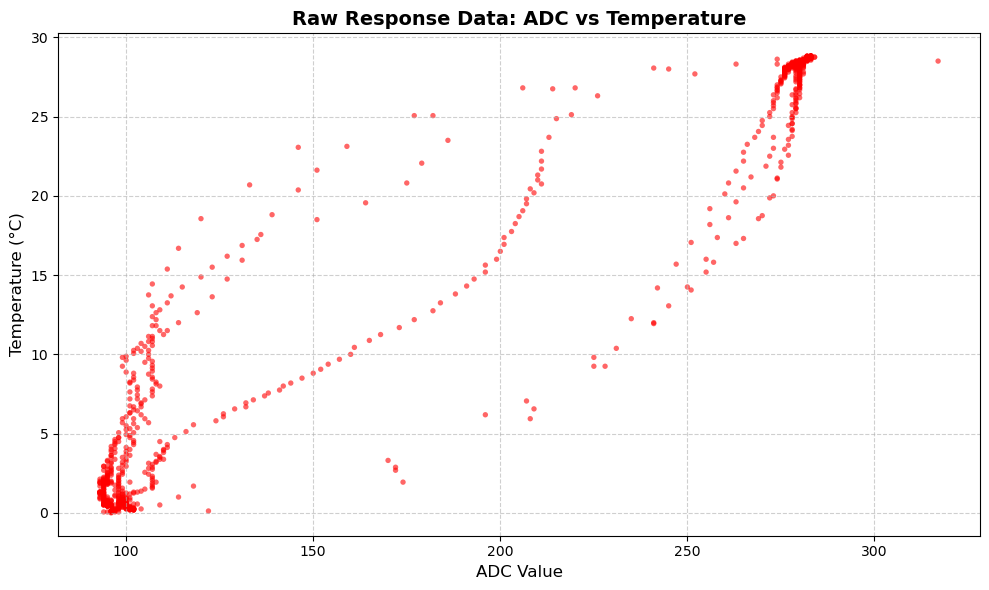

In [125]:
# 1. Plot Raw Heating Data
# Replace 'heating_df' with the actual name of your heating dataframe variable
plot_adc_vs_temp(
    x=raw_response_df['adc'], 
    y=raw_response_df['temp_c'], 
    title="Raw Response Data: ADC vs Temperature", 
    color='red', 
    alpha=0.4
)

In [126]:
# ------------------------------------------------------------
# 1. Find the sharp rises (ice -> room-temp beaker) from the thermistor ADC
# ------------------------------------------------------------
d = raw_response_df.dropna(subset=['adc']).reset_index(drop=True)
t_s = d['time_ms'] / 1000.0
adc = d['adc'].astype(float)

K = 3                                    # look K samples ahead (~4-5 s)
THRESH = 0.3 * (adc.max() - adc.min())   # a rise = ADC climbs > 30% of its full span within K samples
MIN_RUN = 2                              # ignore single-sample noise spikes

jump = ((adc.shift(-K) - adc) > THRESH).fillna(False).values

starts, run = [], 0
for i, flag in enumerate(jump):
    if flag:
        run += 1
        if run == MIN_RUN:
            starts.append(i - MIN_RUN + 1)   # first sample of the rise
    else:
        run = 0

print(f"Found {len(starts)} sharp rises at t = {[round(t_s[i]) for i in starts]} s")

Found 4 sharp rises at t = [371, 719, 1024, 1467] s


In [127]:
# ------------------------------------------------------------
# 2. Cut at every rise -> pieces (each starts at the last cold sample before the jump)
# ------------------------------------------------------------
cuts = [0] + starts + [len(d)]
pieces = []
for a, b in zip(cuts[:-1], cuts[1:]):
    p = d.iloc[a:b].copy()
    p['t_rel_s'] = (p['time_ms'] - p['time_ms'].iloc[0]) / 1000.0   # time restarts at 0 in each piece
    pieces.append(p)
print(f"{len(pieces)} pieces, rows per piece: {[len(p) for p in pieces]}")

5 pieces, rows per piece: [246, 231, 203, 294, 105]


In [128]:
# ------------------------------------------------------------
# 3. Keep only the middle pieces (drop the first and last, which are incomplete)
# ------------------------------------------------------------
middle = pieces[1:-1]
if len(middle) == 3:
    raw_response_1_df, raw_response_2_df, raw_response_3_df = middle
else:
    print(f"WARNING: expected 3 middle pieces, got {len(middle)}. Adjust K / THRESH / MIN_RUN.")

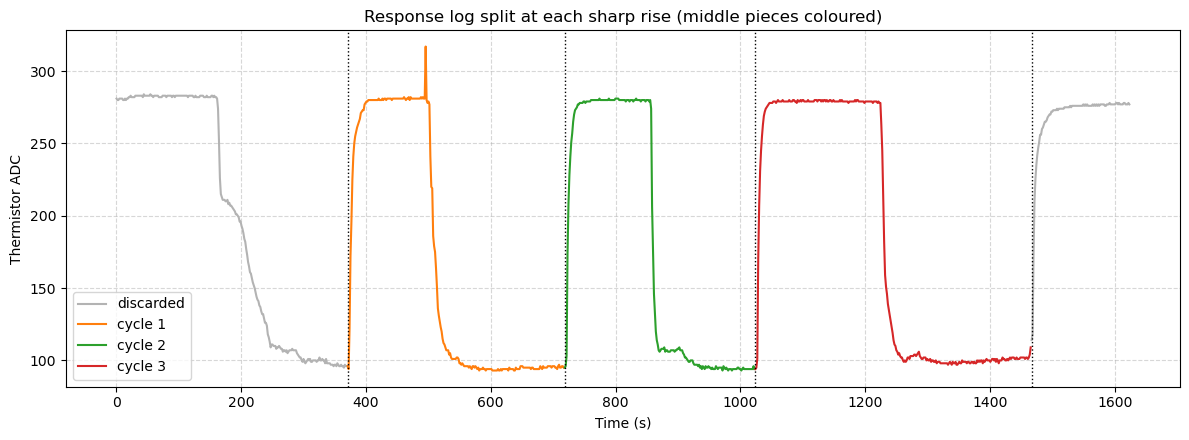

In [129]:
# ------------------------------------------------------------
# 4. Check the cuts visually
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4.5))
for idx, p in enumerate(pieces):
    is_end = idx in (0, len(pieces) - 1)
    ax.plot(p['time_ms'] / 1000, p['adc'], color='0.7' if is_end else f'C{idx}', lw=1.5,
            label='discarded' if is_end and idx == 0 else (None if is_end else f'cycle {idx}'))
for i in starts:
    ax.axvline(t_s[i], color='black', linestyle=':', lw=1)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Thermistor ADC")
ax.set_title("Response log split at each sharp rise (middle pieces coloured)")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

In [130]:
def split_up_down(raw_df, settle=0.03, pad=2, smooth=5):
    """Cut one cycle into the warming part (cold -> room) and the cooling part (room -> cold),
    dropping the flat stretches at both ends."""
    d = raw_df.reset_index(drop=True).copy()
    a = d['adc'].astype(float)
    a_s = a.rolling(smooth, center=True, min_periods=1).median()    # removes short spikes, keeps the edges
    d['adc_clean'] = a_s

    # Levels of the two plateaus, taken from the data
    lo, hi = np.percentile(a_s, [5, 95])
    mid = (lo + hi) / 2
    warm = a_s[a_s > mid].median()
    cold = a_s[a_s < mid].median()
    band = settle * (warm - cold)                                    # "settled" = within this of a plateau

    # UP: from the start until the ADC first reaches the warm plateau
    up_end = int(np.argmax((a_s >= warm - band).values))

    # DOWN: from where it leaves the warm plateau until it first reaches the cold plateau
    after = (a_s.iloc[up_end:] < warm - band).values
    drop_start = up_end + int(np.argmax(after))
    down_end = drop_start + int(np.argmax((a_s.iloc[drop_start:] <= cold + band).values))

    up_df = d.iloc[0 : min(up_end + pad, len(d) - 1) + 1].copy()
    down_df = d.iloc[max(drop_start - pad, 0) : min(down_end + pad, len(d) - 1) + 1].copy()

    for seg in (up_df, down_df):                                     # time restarts at 0 in each segment
        seg['t_seg_s'] = (seg['time_ms'] - seg['time_ms'].iloc[0]) / 1000.0

    info = dict(warm=warm, cold=cold, band=band)
    return up_df, down_df, info

response_1_up_df, response_1_down_df, info1 = split_up_down(raw_response_1_df)
response_2_up_df, response_2_down_df, info2 = split_up_down(raw_response_2_df)
response_3_up_df, response_3_down_df, info3 = split_up_down(raw_response_3_df)

In [131]:
# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print(f"{'Cycle':6s}{'warm ADC':>10s}{'cold ADC':>10s}{'up rows':>9s}{'up s':>7s}{'down rows':>11s}{'down s':>8s}")
for k, (u, dn, inf) in enumerate([(response_1_up_df, response_1_down_df, info1),
                                  (response_2_up_df, response_2_down_df, info2),
                                  (response_3_up_df, response_3_down_df, info3)], start=1):
    print(f"{k:<6d}{inf['warm']:>10.1f}{inf['cold']:>10.1f}{len(u):>9d}{u['t_seg_s'].iloc[-1]:>7.0f}"
          f"{len(dn):>11d}{dn['t_seg_s'].iloc[-1]:>8.0f}")

Cycle   warm ADC  cold ADC  up rows   up s  down rows  down s
1          281.0      95.0       21     30         36      53
2          280.0      95.0       16     23         44      65
3          279.0     100.0       14     20         23      33


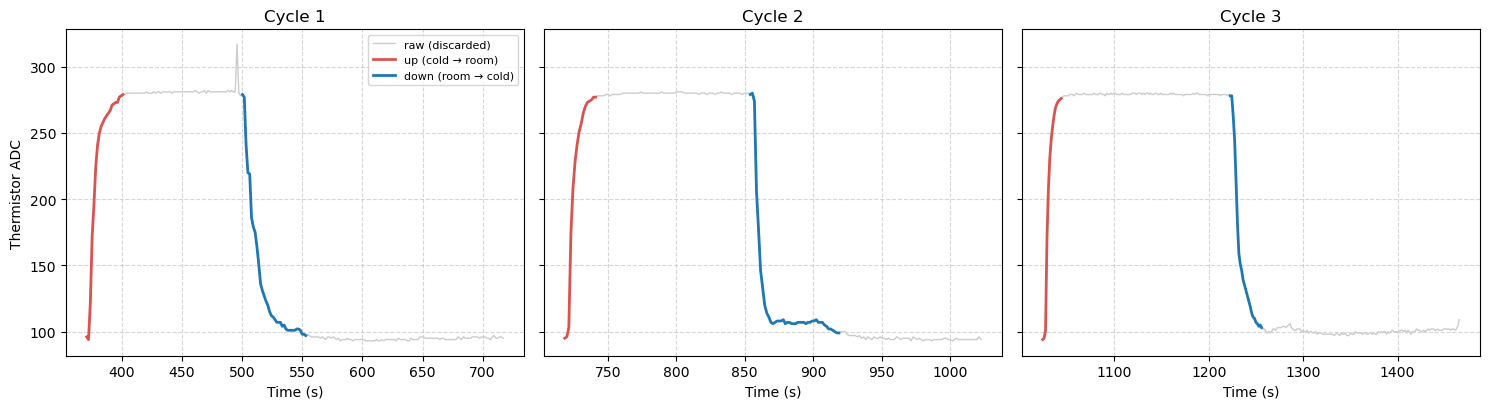

In [132]:
# ------------------------------------------------------------
# Check visually: raw in grey, up in red, down in blue
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for k, (ax, raw, u, dn) in enumerate(zip(
        axes,
        [raw_response_1_df, raw_response_2_df, raw_response_3_df],
        [response_1_up_df, response_2_up_df, response_3_up_df],
        [response_1_down_df, response_2_down_df, response_3_down_df]), start=1):
    ax.plot(raw['time_ms'] / 1000, raw['adc'], color='0.8', lw=1, label='raw (discarded)')
    ax.plot(u['time_ms'] / 1000, u['adc'], color='#d9534f', lw=2, label='up (cold → room)')
    ax.plot(dn['time_ms'] / 1000, dn['adc'], color='#1f77b4', lw=2, label='down (room → cold)')
    ax.set_title(f"Cycle {k}")
    ax.set_xlabel("Time (s)")
    ax.grid(True, linestyle='--', alpha=0.5)
axes[0].set_ylabel("Thermistor ADC")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [133]:
adc_to_temp = np.poly1d([2.1266e-07, -2.8857e-04, 0.22985, -19.0074])

In [134]:
from scipy import stats

LO, HI = 120, 250                              # ADC window for the thermistor
T_LO, T_HI = adc_to_temp(LO), adc_to_temp(HI)  # the same window expressed in °C (used for the DS18B20)
print(f"Window: ADC {LO}-{HI}  =  {T_LO:.1f} - {T_HI:.1f} °C")

def window_slope(t, y, lo, hi, direction):
    """Least-squares line between the first crossing of lo and of hi. direction: 'up' or 'down'."""
    t, y = np.asarray(t, float), np.asarray(y, float)
    ok = ~np.isnan(y); t, y = t[ok], y[ok]
    if direction == 'up':
        a = np.flatnonzero(y > lo)
        if len(a) == 0: return None
        i0 = a[0]; b = np.flatnonzero(y[i0:] >= hi)
    else:
        a = np.flatnonzero(y < hi)
        if len(a) == 0: return None
        i0 = a[0]; b = np.flatnonzero(y[i0:] <= lo)
    if len(b) == 0: return None
    i1 = i0 + b[0]
    if i1 - i0 + 1 < 3: return None
    r = stats.linregress(t[i0:i1 + 1], y[i0:i1 + 1])
    return dict(slope=r.slope, se=r.stderr, r2=r.rvalue ** 2, n=i1 - i0 + 1, dur=t[i1] - t[i0])


Window: ADC 120-250  =  4.8 - 23.7 °C


In [135]:
segments = [
    (1, 'up',   response_1_up_df,   raw_response_1_df),
    (1, 'down', response_1_down_df, raw_response_1_df),
    (2, 'up',   response_2_up_df,   raw_response_2_df),
    (2, 'down', response_2_down_df, raw_response_2_df),
    (3, 'up',   response_3_up_df,   raw_response_3_df),
    (3, 'down', response_3_down_df, raw_response_3_df),
]

rows = []
for cyc, direction, seg, raw in segments:
    t = seg['t_seg_s']
    adc_c = seg['adc_clean']

    th_adc = window_slope(t, adc_c, LO, HI, direction)                              # dADC/dt
    th_T   = window_slope(t, adc_to_temp(adc_c.values), T_LO, T_HI, direction)      # thermistor dT/dt

    # DS18B20: same temperature window, searched in the full cycle (it lags, so its window falls later)
    raw_part = raw if direction == 'up' else raw[raw['time_ms'] >= seg['time_ms'].iloc[0]]
    ds = window_slope(raw_part['time_ms'] / 1000, raw_part['temp_c'], T_LO, T_HI, direction)

    row = {"Cycle": cyc, "Dir": direction}
    if th_adc:
        row.update({"Points": th_adc['n'], "Window (s)": f"{th_adc['dur']:.1f}",
                    "dADC/dt (cnt/s)": f"{th_adc['slope']:+.2f} ± {th_adc['se']:.2f}",
                    "R²": f"{th_adc['r2']:.4f}"})
    if th_T:
        row["Thermistor dT/dt (°C/s)"] = f"{th_T['slope']:+.3f}"
    if ds:
        row["DS18B20 dT/dt (°C/s)"] = f"{ds['slope']:+.3f}"
        row["DS points"] = ds['n']
        if th_T:
            row["Thermistor / DS speed"] = f"{abs(th_T['slope'] / ds['slope']):.1f}x"
    rows.append(row)

result_df = pd.DataFrame(rows)
print(result_df.to_string(index=False))
print("\nTreat any window with fewer than 5 points as unreliable.")

 Cycle  Dir  Points Window (s) dADC/dt (cnt/s)     R² Thermistor dT/dt (°C/s) DS18B20 dT/dt (°C/s)  DS points Thermistor / DS speed
     1   up       6        7.5   +16.63 ± 2.13 0.9382                  +2.386               +0.782         15                  3.1x
     1 down      13       18.1    -6.77 ± 0.45 0.9527                  -1.012               -0.410         30                  2.5x
     2   up       5        6.0   +12.43 ± 1.83 0.9387                  +1.686               +0.933         13                  1.8x
     2 down       5        6.0   -14.35 ± 1.71 0.9590                  -2.206               -0.203         43                 10.9x
     3   up       5        6.0   +13.83 ± 2.10 0.9350                  +1.875               +0.985         12                  1.9x
     3 down      12       16.6    -6.47 ± 0.99 0.8097                  -0.973               -0.235         41                  4.1x

Treat any window with fewer than 5 points as unreliable.


Plateau      N   mean ΔT (°C)   std (°C)
room       340          -1.03       0.10
ice        240          -0.01       1.02


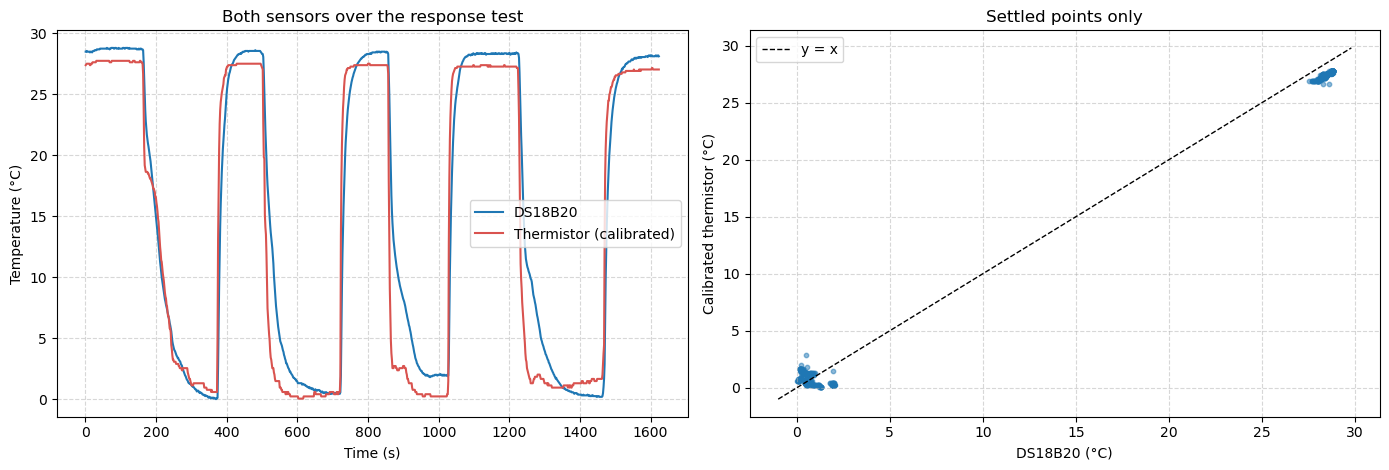

In [136]:
d = raw_response_df.dropna(subset=['adc', 'temp_c']).copy()
d['t_s'] = d['time_ms'] / 1000
d['t_cal'] = adc_to_temp(d['adc'].rolling(5, center=True, min_periods=1).median())
d['diff'] = d['t_cal'] - d['temp_c']

# settled = ADC on a plateau AND the DS18B20 itself nearly flat (it lags, so check it separately)
ds_rate = d['temp_c'].diff(10) / d['t_s'].diff(10)
warm = (d['adc'] > 270) & (ds_rate.abs() < 0.03)
cold = (d['adc'] < 110) & (ds_rate.abs() < 0.03)

print(f"{'Plateau':8s}{'N':>6s}{'mean ΔT (°C)':>15s}{'std (°C)':>11s}")
for name, m in [("room", warm), ("ice", cold)]:
    print(f"{name:8s}{m.sum():>6d}{d.loc[m, 'diff'].mean():>15.2f}{d.loc[m, 'diff'].std():>11.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))
ax1.plot(d['t_s'], d['temp_c'], color='#1f77b4', label='DS18B20')
ax1.plot(d['t_s'], d['t_cal'], color='#d9534f', label='Thermistor (calibrated)')
ax1.set_xlabel("Time (s)"); ax1.set_ylabel("Temperature (°C)")
ax1.set_title("Both sensors over the response test"); ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.5)

s = warm | cold
ax2.scatter(d.loc[s, 'temp_c'], d.loc[s, 't_cal'], s=10, alpha=0.5)
lims = [d.loc[s, 'temp_c'].min() - 1, d.loc[s, 'temp_c'].max() + 1]
ax2.plot(lims, lims, 'k--', lw=1, label='y = x')
ax2.set_xlabel("DS18B20 (°C)"); ax2.set_ylabel("Calibrated thermistor (°C)")
ax2.set_title("Settled points only"); ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

In [137]:
from scipy.optimize import curve_fit

cycles = [
    (1, raw_response_1_df, response_1_up_df, response_1_down_df),
    (2, raw_response_2_df, response_2_up_df, response_2_down_df),
    (3, raw_response_3_df, response_3_up_df, response_3_down_df),
]

def cross_time(t, y, level, rising=True):
    """Time of the first crossing of `level`, linearly interpolated between samples."""
    t, y = np.asarray(t, float), np.asarray(y, float)
    idx = np.flatnonzero(y >= level) if rising else np.flatnonzero(y <= level)
    if len(idx) == 0 or idx[0] == 0:
        return np.nan
    i = idx[0]
    return t[i - 1] + (level - y[i - 1]) * (t[i] - t[i - 1]) / (y[i] - y[i - 1])

def step_up(t, y_i, y_f, tau, t0):
    """Delayed first-order step: flat at y_i until t0, then exponential approach to y_f."""
    return np.where(t < t0, y_i, y_f + (y_i - y_f) * np.exp(-(t - t0) / tau))

def fit_up(t, y):
    y_i0, y_f0 = np.median(y[:3]), np.median(y[-8:])
    first = t[np.argmax(np.abs(y - y_i0) > 0.1 * abs(y_f0 - y_i0))]
    p0 = [y_i0, y_f0, 4.0, first - 1.0]
    bounds = ([y_i0 - 3, y_f0 - 3, 0.2, t.min() - 3], [y_i0 + 3, y_f0 + 3, 120.0, t.max()])
    try:
        popt, pcov = curve_fit(step_up, t, y, p0=p0, bounds=bounds, maxfev=20000)
    except Exception as e:
        print("fit failed:", e)
        return None
    y_i, y_f, tau, t0 = popt
    resid = y - step_up(t, *popt)
    t10 = cross_time(t, y, y_i + 0.1 * (y_f - y_i))
    t90 = cross_time(t, y, y_i + 0.9 * (y_f - y_i))
    return dict(tau=tau, tau_se=np.sqrt(pcov[2, 2]), t0=t0, y_i=y_i, y_f=y_f,
                rmse=np.sqrt(np.mean(resid ** 2)), rise_1090=t90 - t10, t=t, y=y, popt=popt)


In [138]:
rows, fits = [], {}
for cyc, raw, up, down in cycles:
    t_start = up['time_ms'].iloc[0]
    t_end = up['time_ms'].iloc[-1] + 25_000        # 25 s of plateau after the rise pins the final value
    w = raw[(raw['time_ms'] >= t_start) & (raw['time_ms'] <= t_end)].dropna(subset=['adc', 'temp_c'])
    t = ((w['time_ms'] - t_start) / 1000).values
    adc_s = w['adc'].astype(float).rolling(5, center=True, min_periods=1).median().values
    series = {"Thermistor": adc_to_temp(adc_s), "DS18B20": w['temp_c'].values}   # same rows for both sensors

    fits[cyc] = {}
    for name, y in series.items():
        f = fit_up(t, y)
        fits[cyc][name] = f
        if f is None:
            continue
        rows.append({"Cycle": cyc, "Sensor": name, "tau (s)": f['tau'], "tau se (s)": f['tau_se'],
                     "delay t0 (s)": f['t0'], "10-90% measured (s)": f['rise_1090'],
                     "10-90% from tau (s)": 2.197 * f['tau'], "Fit RMSE (°C)": f['rmse'],
                     "T start (°C)": f['y_i'], "T end (°C)": f['y_f']})


In [139]:

tab_up = pd.DataFrame(rows)
print(tab_up.round(2).to_string(index=False))
print()
for s in ["Thermistor", "DS18B20"]:
    sub = tab_up[tab_up["Sensor"] == s]
    print(f"{s:10s}: tau = {sub['tau (s)'].mean():.2f} ± {sub['tau (s)'].std():.2f} s | "
          f"10-90% rise = {sub['10-90% measured (s)'].mean():.1f} ± {sub['10-90% measured (s)'].std():.1f} s "
          f"(mean ± std over {len(sub)} cycles)")

 Cycle     Sensor  tau (s)  tau se (s)  delay t0 (s)  10-90% measured (s)  10-90% from tau (s)  Fit RMSE (°C)  T start (°C)  T end (°C)
     1 Thermistor     4.21        0.18          2.27                10.45                 9.24           0.53          1.74       27.11
     1    DS18B20    11.39        0.25          3.09                24.99                25.02           0.32          0.08       28.14
     2 Thermistor     3.25        0.12          2.77                 8.55                 7.14           0.48          0.90       27.11
     2    DS18B20     9.75        0.12          3.80                21.99                21.41           0.17          0.48       27.20
     3 Thermistor     3.06        0.07          2.85                 7.47                 6.73           0.31          0.68       27.13
     3    DS18B20     9.36        0.14          3.90                21.62                20.56           0.19          1.94       27.71

Thermistor: tau = 3.51 ± 0.61 s | 10-90% rise =

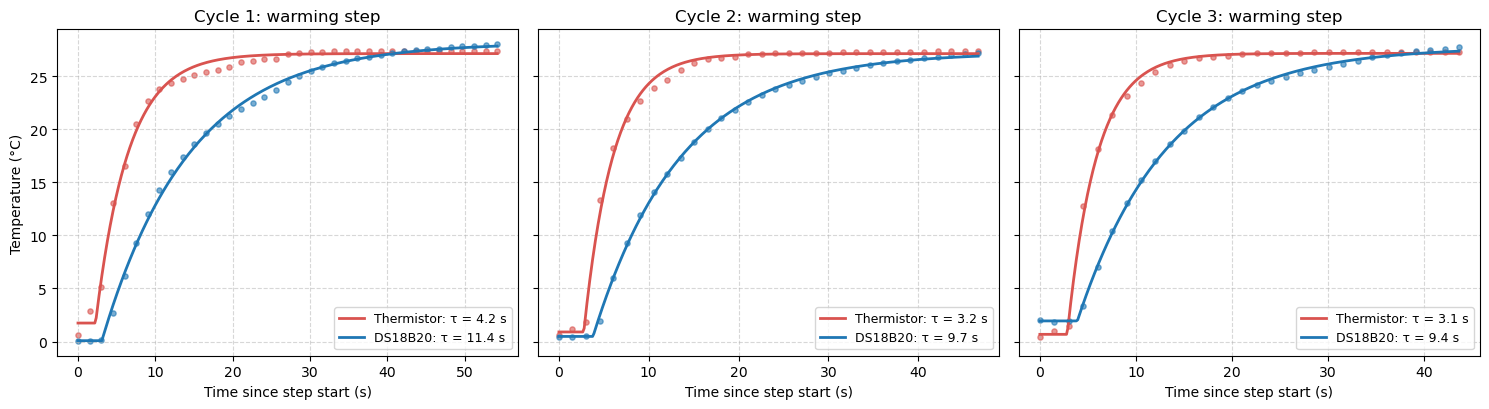

In [140]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
colors = {"Thermistor": "#d9534f", "DS18B20": "#1f77b4"}
for ax, (cyc, *_) in zip(axes, cycles):
    for name, f in fits[cyc].items():
        if f is None:
            continue
        ax.scatter(f['t'], f['y'], s=14, color=colors[name], alpha=0.6)
        tt = np.linspace(f['t'].min(), f['t'].max(), 300)
        ax.plot(tt, step_up(tt, *f['popt']), color=colors[name], lw=2, label=f"{name}: τ = {f['tau']:.1f} s")
    ax.set_title(f"Cycle {cyc}: warming step")
    ax.set_xlabel("Time since step start (s)")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=9)
axes[0].set_ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

In [141]:
EXCLUDE = {2}     # cycles left out of the mean (cycle 2 had only a 5-point slope window)

def fall_profile(t, y):
    warm, cold = np.median(y[:3]), np.median(y[-10:])
    amp = warm - cold
    t10 = cross_time(t, y, warm - 0.1 * amp, rising=False)    # 10% of the drop completed
    t90 = cross_time(t, y, warm - 0.9 * amp, rising=False)    # 90% of the drop completed
    return dict(t10=t10, t90=t90, fall_1090=t90 - t10, warm=warm, cold=cold)

rows, wins = [], {}
for cyc, raw, up, down in cycles:
    t_start = down['time_ms'].iloc[0] - 5_000          # start 5 s before the drop, run to the end of the piece
    w = raw[raw['time_ms'] >= t_start].dropna(subset=['adc', 'temp_c'])
    t = ((w['time_ms'] - t_start) / 1000).values
    adc_s = w['adc'].astype(float).rolling(5, center=True, min_periods=1).median().values
    series = {"Thermistor": adc_to_temp(adc_s), "DS18B20": w['temp_c'].values}
    wins[cyc] = (t, series)

    res = {name: fall_profile(t, y) for name, y in series.items()}
    for name, r in res.items():
        rows.append({"Cycle": cyc, "Sensor": name, "10-90% fall (s)": r['fall_1090'],
                     "drop starts at (s)": r['t10'], "warm (°C)": r['warm'], "cold (°C)": r['cold'],
                     "Used in mean": cyc not in EXCLUDE})
    print(f"Cycle {cyc}: DS18B20 starts falling {res['DS18B20']['t10'] - res['Thermistor']['t10']:.1f} s after the thermistor")


Cycle 1: DS18B20 starts falling 3.2 s after the thermistor
Cycle 2: DS18B20 starts falling 2.0 s after the thermistor
Cycle 3: DS18B20 starts falling 3.6 s after the thermistor


In [142]:
tab_dn = pd.DataFrame(rows)
print("\n" + tab_dn.round(2).to_string(index=False))
print()
for s in ["Thermistor", "DS18B20"]:
    sub = tab_dn[(tab_dn["Sensor"] == s) & tab_dn["Used in mean"]]
    print(f"{s:10s}: 10-90% fall = {sub['10-90% fall (s)'].mean():.1f} ± {sub['10-90% fall (s)'].std():.1f} s "
          f"(cycles {sorted(sub['Cycle'])})")




 Cycle     Sensor  10-90% fall (s)  drop starts at (s)  warm (°C)  cold (°C)  Used in mean
     1 Thermistor            23.88                7.32      27.34       0.41          True
     1    DS18B20            60.02               10.56      28.44       0.44          True
     2 Thermistor            10.83                8.36      27.40       0.23         False
     2    DS18B20            66.29               10.39      28.44       1.94         False
     3 Thermistor            18.30                8.47      27.22       1.66          True
     3    DS18B20            81.63               12.09      28.37       0.19          True

Thermistor: 10-90% fall = 21.1 ± 3.9 s (cycles [1, 3])
DS18B20   : 10-90% fall = 70.8 ± 15.3 s (cycles [1, 3])


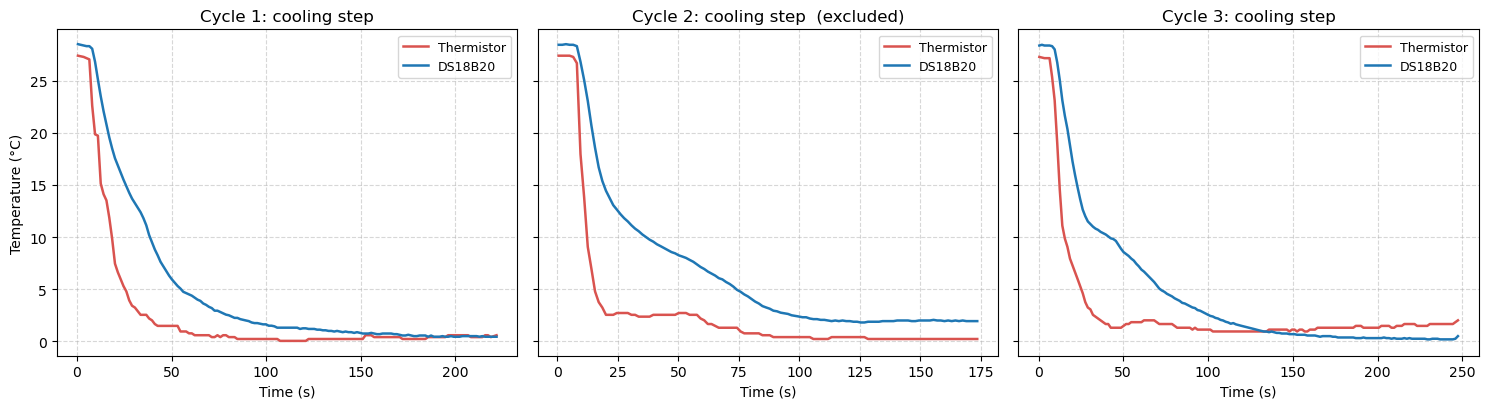

In [143]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, cyc in zip(axes, wins):
    t, series = wins[cyc]
    ax.plot(t, series["Thermistor"], color="#d9534f", lw=1.8, label="Thermistor")
    ax.plot(t, series["DS18B20"], color="#1f77b4", lw=1.8, label="DS18B20")
    ax.set_title(f"Cycle {cyc}: cooling step" + ("  (excluded)" if cyc in EXCLUDE else ""))
    ax.set_xlabel("Time (s)")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=9)
axes[0].set_ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()